# 🎥 Video 13: Chemical Reactions & BRICS-Based Molecular Design
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 8 — Advanced RDKit (Topics 41, 42, 43)
* **Target Audience:** Medicinal Chemists, Computational Chemists, AI Drug Designers

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 04:30** | Reaction SMARTS: The Language of Chemical Transformations
* **04:30 - 09:30** | Creating Reactions with `AllChem.ReactionFromSmarts` & `rxn.RunReactants`
* **09:30 - 14:30** | Virtual Combinatorial Library Enumeration (Amide Couplings, Click Chemistry)
* **14:30 - 19:30** | Molecular Fragmentation: BRICS (Bioisosteric Replacement Initiated by Chemical Substructures)
* **19:30 - 24:30** | Fragment-Based Molecular Assembly: Designing New Molecules with `BRICSBuild`
* **24:30 - 28:00** | Applying Drug-Likeness Filters to Generated Virtual Libraries
* **28:00 - 30:00** | Hands-On Challenge & Summary

---

### 🎯 Learning Objectives
1. Write and interpret Reaction SMARTS with reactant and product atom-mapping numbers (`:1`, `:2`).
2. Run virtual organic reactions and handle multiple stereoisomeric/regiochemical products.
3. Enumerate combinatorial libraries from sets of building blocks (acids $\times$ amines).
4. Fragment drug molecules along 16 retrosynthetically sensible BRICS cleavage rules.
5. Generate novel drug-like molecules computationally using BRICS fragment assembly.

In [1]:
# Step 0: Imports and Setup
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, BRICS, Descriptors
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd

IPythonConsole.ipython_useSVG = True

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. Reaction SMARTS Fundamentals
A chemical reaction in SMARTS format is defined as:
`Reactant_1 . Reactant_2 >> Product_1 . Product_2`
Numbers after colons (`:1`, `:2`) are **atom-mapping indices** that track which reactant atoms map to which product atoms!

### Common Reaction: Amide Bond Coupling
Carboxylic acid + Primary/Secondary Amine $\to$ Amide:
`[C:1](=O)[OH].[N:2][C:3] >> [C:1](=O)[N:2][C:3]`

Number of product trajectories: 1
Product SMILES: CCNC(=O)c1ccccc1


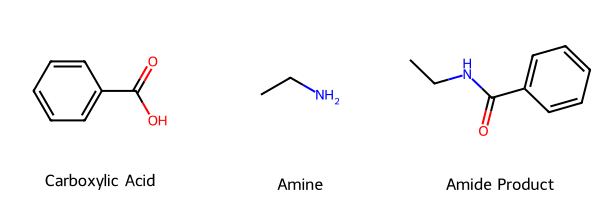

In [2]:
# Compile amide coupling reaction
amide_rxn_smarts = "[C:1](=O)[O;H1].[NX3;H2,H1:2]>>[C:1](=O)[N:2]"
rxn = AllChem.ReactionFromSmarts(amide_rxn_smarts)

# Define reactants: Benzoic acid + Ethylamine
acid = Chem.MolFromSmiles("c1ccccc1C(=O)O")
amine = Chem.MolFromSmiles("CCN")

# Run reaction
products = rxn.RunReactants((acid, amine))

print(f"Number of product trajectories: {len(products)}")
product_mol = products[0][0]
print("Product SMILES:", Chem.MolToSmiles(product_mol))

Draw.MolsToGridImage([acid, amine, product_mol], legends=["Carboxylic Acid", "Amine", "Amide Product"])

## 2. Combinatorial Library Enumeration
Let's assemble a virtual combinatorial library by reacting 3 carboxylic acids with 3 amines ($3 \times 3 = 9$ virtual products)!

✅ Successfully enumerated 9 virtual amide compounds!


,Acid,Amine,Product_SMILES,MW,LogP
0,Benzoic Acid,Morpholine,O=C(c1ccccc1)N1CCOCC1,191.23,1.16
1,Benzoic Acid,Cyclopropylamine,O=C(NC1CC1)c1ccccc1,161.20,1.58
2,Benzoic Acid,Aniline,O=C(Nc1ccccc1)c1ccccc1,197.24,2.94
3,Ibuprofen,Morpholine,CC(C)Cc1ccc(C(C)C(=O)N2CCOCC2)cc1,275.39,2.85
4,Ibuprofen,Cyclopropylamine,CC(C)Cc1ccc(C(C)C(=O)NC2CC2)cc1,245.37,3.27


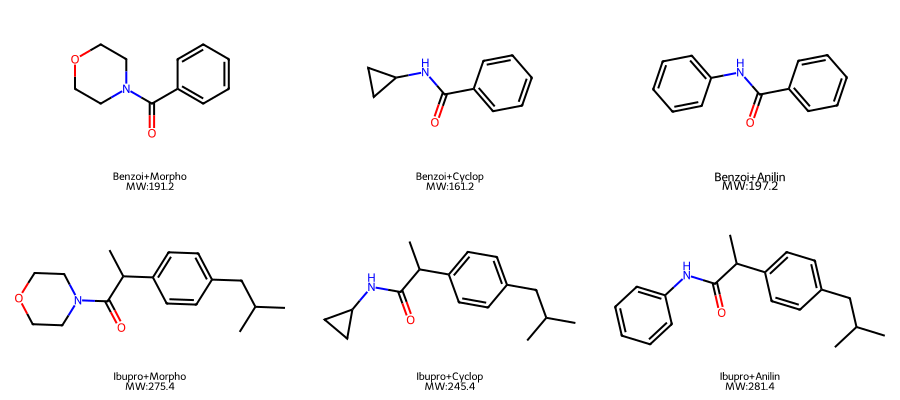

In [3]:
acids = [
    ("Benzoic Acid", "c1ccccc1C(=O)O"),
    ("Ibuprofen", "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Nicotinic Acid", "c1cnccc1C(=O)O")
]

amines = [
    ("Morpholine", "C1COCCN1"),
    ("Cyclopropylamine", "C1CC1N"),
    ("Aniline", "c1ccccc1N")
]

virtual_library = []
library_mols = []
library_legends = []

for a_name, a_smi in acids:
    mol_a = Chem.MolFromSmiles(a_smi)
    for b_name, b_smi in amines:
        mol_b = Chem.MolFromSmiles(b_smi)
        prod_sets = rxn.RunReactants((mol_a, mol_b))
        
        if prod_sets:
            prod = prod_sets[0][0]
            Chem.SanitizeMol(prod)
            prod_smi = Chem.MolToSmiles(prod)
            mw = Descriptors.MolWt(prod)
            logp = Descriptors.MolLogP(prod)
            
            virtual_library.append({
                "Acid": a_name,
                "Amine": b_name,
                "Product_SMILES": prod_smi,
                "MW": round(mw, 2),
                "LogP": round(logp, 2)
            })
            library_mols.append(prod)
            library_legends.append(f"{a_name[:6]}+{b_name[:6]}\nMW:{mw:.1f}")

df_virtual = pd.DataFrame(virtual_library)
print(f"✅ Successfully enumerated {len(df_virtual)} virtual amide compounds!")
display(df_virtual.head(5))

Draw.MolsToGridImage(library_mols[:6], legends=library_legends[:6], molsPerRow=3, subImgSize=(300, 200))

## 3. BRICS Molecular Fragmentation
**BRICS (Bioisosteric Replacement Initiated by Chemical Substructures):**
Decomposes molecules into synthetically accessible fragments by cleaving bonds matching 16 common chemical reactions (e.g. amides, esters, aromatic C-N, ring-spiro bonds).
Each fragment retains dummy isotope labels (e.g., `[1*]`, `[5*]`) indicating its compatible connection points!

Imatinib decomposed into 9 BRICS fragments:
  Fragment 1: [16*]c1ccc(C)c([16*])c1
  Fragment 2: [5*]N[5*]
  Fragment 3: [14*]c1ccnc([14*])n1
  Fragment 4: [16*]c1cccnc1
  Fragment 5: [5*]N[5*]
  Fragment 6: [1*]C([6*])=O
  Fragment 7: [16*]c1ccc([16*])cc1
  Fragment 8: [4*]C[8*]
  Fragment 9: [5*]N1CCN(C)CC1


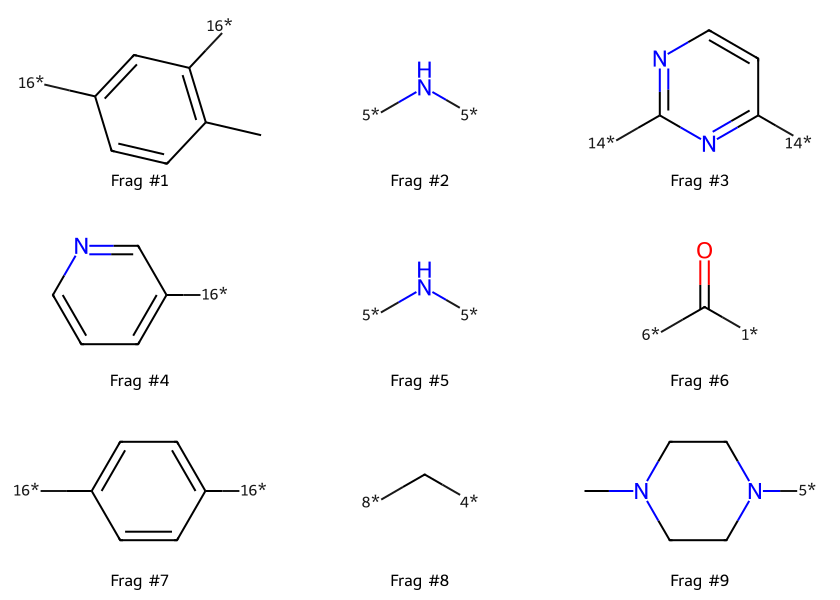

In [4]:
# Fragment Imatinib using BRICS
imatinib_smi = "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"
imatinib = Chem.MolFromSmiles(imatinib_smi)

# Break BRICS bonds
brics_frags = BRICS.BreakBRICSBonds(imatinib)
frag_list = Chem.GetMolFrags(brics_frags, asMols=True)

print(f"Imatinib decomposed into {len(frag_list)} BRICS fragments:")
frag_smiles = [Chem.MolToSmiles(f) for f in frag_list]
for i, fs in enumerate(frag_smiles, 1):
    print(f"  Fragment {i}: {fs}")

Draw.MolsToGridImage(frag_list, legends=[f"Frag #{i+1}" for i in range(len(frag_list))], molsPerRow=3, subImgSize=(280, 200))

## 4. Fragment-Based Virtual Design with `BRICSBuild`
Now let's reverse the process: given a pool of retrosynthetic fragments, `BRICS.BRICSBuild` assembles them according to chemical compatibility rules to generate novel candidate molecules!

Generated 6 novel virtual molecules!


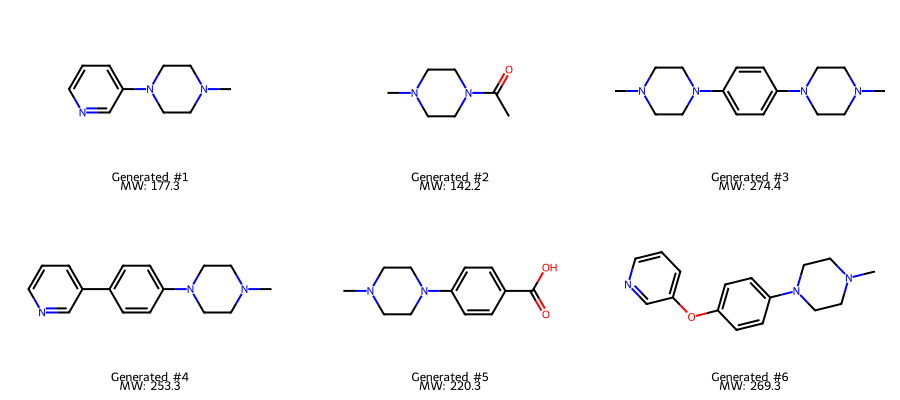

In [5]:
# Assemble fragments from Imatinib and Aspirin
aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
combined_frags = list(Chem.GetMolFrags(BRICS.BreakBRICSBonds(imatinib), asMols=True))
combined_frags.extend(list(Chem.GetMolFrags(BRICS.BreakBRICSBonds(aspirin), asMols=True)))

# Generate novel molecules using BRICS generator
builder = BRICS.BRICSBuild(combined_frags)

novel_molecules = []
for i, mol in enumerate(builder):
    if i >= 6:  # Limit to 6 for speed
        break
    mol.UpdatePropertyCache(strict=False)
    Chem.SanitizeMol(mol)
    novel_molecules.append(mol)

print(f"Generated {len(novel_molecules)} novel virtual molecules!")
Draw.MolsToGridImage(
    novel_molecules,
    legends=[f"Generated #{i+1}\nMW: {Descriptors.MolWt(m):.1f}" for i, m in enumerate(novel_molecules)],
    molsPerRow=3,
    subImgSize=(300, 200)
)

## 5. 🎯 Video Hands-On Challenge & Solution
### Problem:
1. Define a Fischer Esterification reaction SMARTS:
   Carboxylic acid (`[C:1](=O)[O;H1]`) + Alcohol (`[O;H1:2][C:3]`) $\to$ Ester (`[C:1](=O)[O:2][C:3]`).
2. React Salicylic acid with Methanol to synthesize Methyl salicylate (Oil of Wintergreen).
3. Sanitize and display the product structure.

Esterification Product SMILES: COC(=O)c1ccccc1O


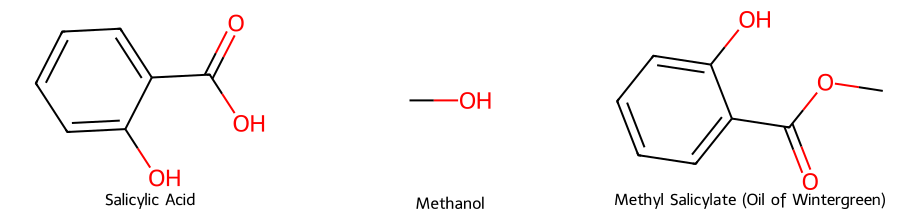

In [6]:
# Fischer Esterification Reaction SMARTS
ester_smarts = "[C:1](=O)[O;H1].[O;H1:2][C:3]>>[C:1](=O)[O:2][C:3]"
ester_rxn = AllChem.ReactionFromSmarts(ester_smarts)

salicylic_acid = Chem.MolFromSmiles("Oc1ccccc1C(=O)O") # Salicylic acid
methanol = Chem.MolFromSmiles("CO")                   # Methanol

ester_products = ester_rxn.RunReactants((salicylic_acid, methanol))
methyl_salicylate = ester_products[0][0]
Chem.SanitizeMol(methyl_salicylate)

print("Esterification Product SMILES:", Chem.MolToSmiles(methyl_salicylate))

Draw.MolsToGridImage(
    [salicylic_acid, methanol, methyl_salicylate],
    legends=["Salicylic Acid", "Methanol", "Methyl Salicylate (Oil of Wintergreen)"],
    molsPerRow=3,
    subImgSize=(300, 220)
)

## 6. Summary & Key Takeaways
* **Reaction SMARTS** enables programmatic synthesis of virtual chemical libraries for drug screening.
* **BRICS fragmentation** breaks molecules at synthetically sensible bonds, providing building blocks for fragment-based drug design (FBDD).
* **`BRICSBuild`** assembles fragment libraries into novel, synthetically feasible drug-like candidates.

**Next Up in Video 14:** **3D Conformer Generation & Geometry Optimization** — embedding 3D coordinates, force field minimization (UFF/MMFF94s), and RMSD alignment!